## Nautilius - Nested sampling CPL

In [ ]:
from scipy.stats import norm
from nautilus import Prior
import numpy as np
from scipy.stats import multivariate_normal


prior = Prior()
prior.add_parameter('w0', dist=(-1.5, -0.5))
prior.add_parameter('wa', dist=(-3.0, 2.0))
prior.add_parameter('Om0', dist=(0.1, 0.5))
prior.add_parameter('h0', dist=(0.3, 1.2))

### Model

In [7]:
import toolscosmo as tcm

def model(param, zz):
    w0, wa, Om0, h0 = param

    p = tcm.par(DE='CPL')
    p.DE.w0 = w0
    p.DE.wa = wa
    p.cosmo.Om = Om0
    p.cosmo.h = h0
    
    return tcm.distance_modulus(zz, p)

### Pantheon+ data 

In [ ]:
# Pantheon+ data
sne_p    = tcm.load_sne_data('pantheon+')
raw_p    = sne_p['raw']
is_calib = raw_p['IS_CALIBRATOR'].astype(bool)
print(f"Loaded {len(sne_p['z'])} SNe Ia  "
      f"({is_calib.sum()} SH0ES Cepheid calibrators, "
      f"{(~is_calib).sum()} Hubble-flow SNe)")

z_p   = sne_p['z']
mu_p  = sne_p['mu']
dmu_p = sne_p['mu_err']

# MU_SH0ES already carries the SH0ES absolute calibration;
# we still marginalise over M_B as a nuisance (same as Pantheon 2018 above).
p_ref    = cpl_par(-1.0, 0.0)
mu_ref_p = tcm.distance_modulus(z_p, p_ref)
M_eff_p  = np.average(mu_p - mu_ref_p, weights=1/dmu_p**2)
mu_obs_p = mu_p - M_eff_p


Loaded 1701 SNe Ia  (77 SH0ES Cepheid calibrators, 1624 Hubble-flow SNe)


### Sampling

In [ ]:
def likelihood(param_dict):

    w0 = param_dict['w0']
    wa = param_dict['wa']
    Om0 = param_dict['Om0']
    h0 = param_dict['h0']

    mu_model = model([w0, wa, Om0, h0], z_p)

    delta = mu_obs_p - mu_model

    chi2 = np.sum((delta / dmu_p)**2)

    return -0.5 * chi2

In [10]:
from nautilus import Sampler

sampler = Sampler(prior, likelihood, n_live=1000)
sampler.run(verbose=True)

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 27     | 1        | 4        | 31300    | N/A    | 10014 | -448.05  


True

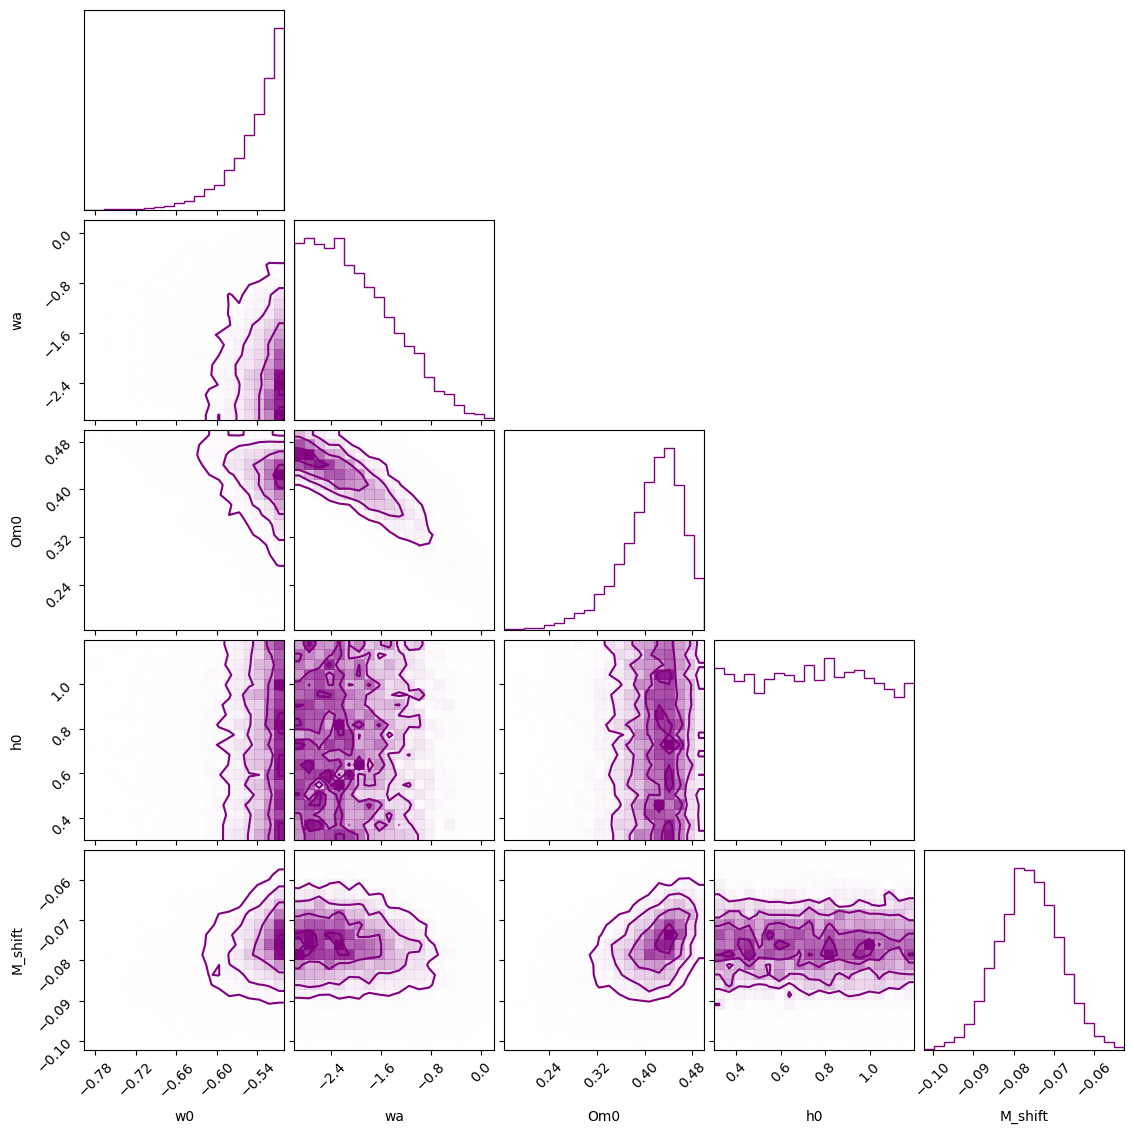

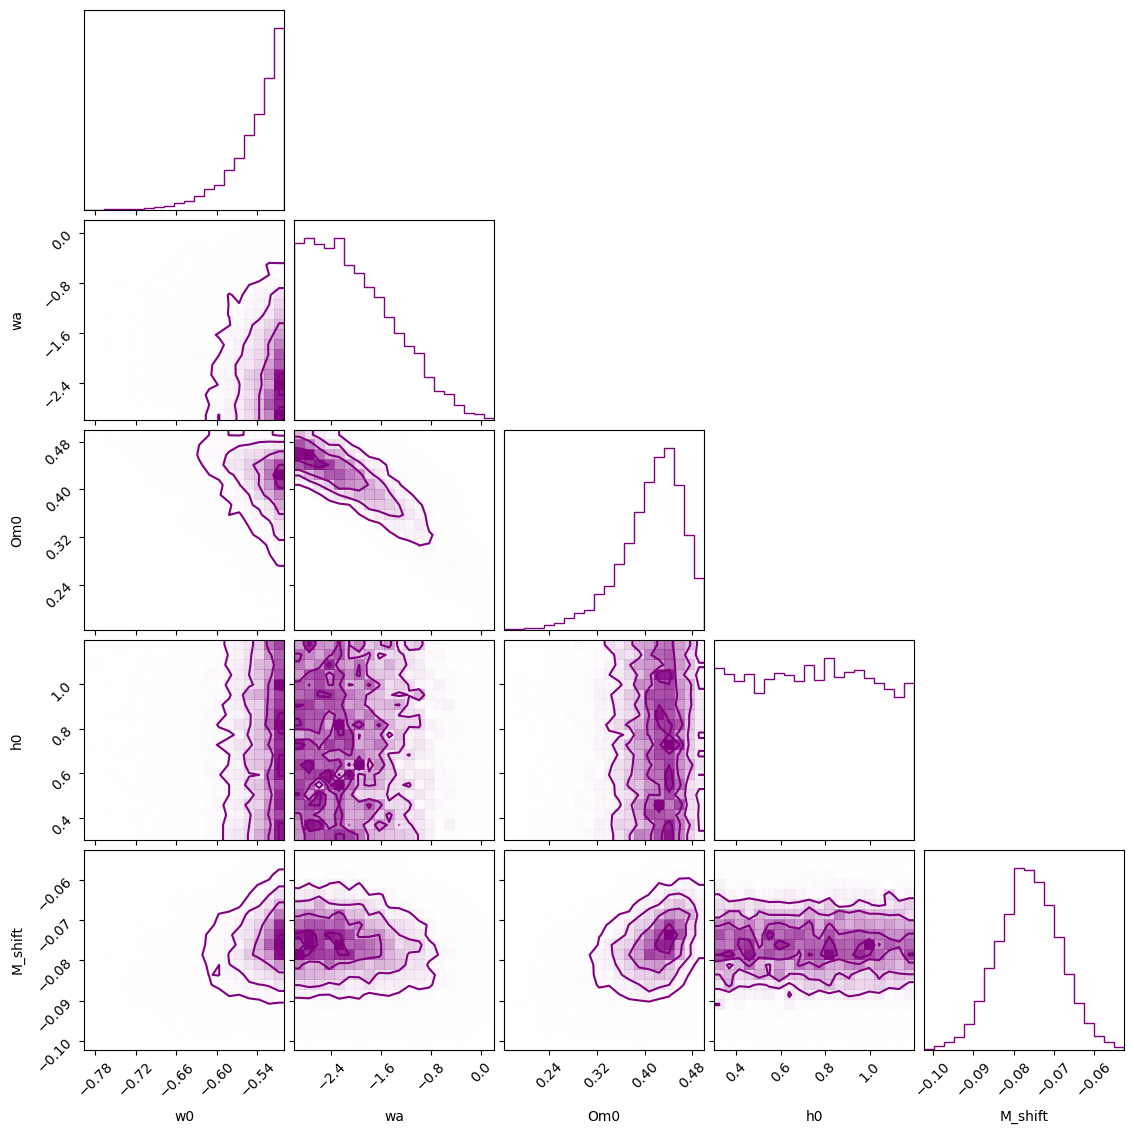

In [11]:
import corner
import matplotlib.pyplot as plt

points, log_w, log_l = sampler.posterior()
corner.corner(
    points, weights=np.exp(log_w), bins=20, labels=prior.keys, color='purple',
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)))

